# Lab 1

## Task 1 - EDA in python

In [ ]:
import duckdb
from pathlib import Path

# deifines duckdb path and recreates the file everytime this command runs.
duckdb_path = "data/sakila.duckdb"
Path(duckdb_path).unlink(missing_ok=True)

# Opens a duckdb connection and opens load_sakila that contains cretae table and insert. 
# With statment ensures both are autmatically closed.
with duckdb.connect(duckdb_path) as conn, open("sql/load_sakila.sql") as ingest_script:
    conn.sql(ingest_script.read())

    # sql query, returns description and selects all rows from film table. 
    # Also converts them into pandas dataframe.
    description = conn.sql("DESC;").df()
    films = conn.sql("FROM film;").df()

# Displays first two rows of films to verify that data loaded.
films.head(2)

,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,<NA>,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2021-03-06 15:52:00
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,<NA>,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2021-03-06 15:52:00


In [ ]:
# stores pandas dataframes
dfs = {}

# opens connection to duckdb database, description contains names of tablles and loops once per table.
with duckdb.connect(duckdb_path) as conn:
    for name in description["name"]:
        dfs[name] = conn.sql(f"FROM {name};").df()

# returns all keys in the created dictionary
dfs.keys()

dict_keys(['actor', 'address', 'category', 'city', 'country', 'customer', 'customer_list', 'film', 'film_actor', 'film_category', 'film_list', 'film_text', 'inventory', 'language', 'payment', 'rental', 'sales_by_film_category', 'sales_by_store', 'staff', 'staff_list', 'store'])

In [ ]:
# These tables only exist in memory and only in this python session. Does not write back do duckdb file.
film_names = ("actor", "address", "category", "city", "country", "customer", 
              "customer_list", "film", "film_actor", "film_category", 
              "film_list", "film_text", "inventory", "language", "payment", 
              "rental", "sales_by_film_category", "sales_by_store", "staff", 
              "staff_list", "store")


for film_name in film_names:
    duckdb.register(film_name, dfs[film_name])

duckdb.sql("desc;").df()

,database,schema,name,column_names,column_types,temporary
0,temp,main,actor,"[actor_id, first_name, last_name, last_update]","[DOUBLE, VARCHAR, VARCHAR, TIMESTAMP]",True
1,temp,main,address,"[address_id, address, address2, district, city...","[BIGINT, VARCHAR, ""NULL"", VARCHAR, BIGINT, VAR...",True
2,temp,main,category,"[category_id, name, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",True
3,temp,main,city,"[city_id, city, country_id, last_update]","[BIGINT, VARCHAR, BIGINT, TIMESTAMP]",True
4,temp,main,country,"[country_id, country, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",True
5,temp,main,customer,"[customer_id, store_id, first_name, last_name,...","[BIGINT, BIGINT, VARCHAR, VARCHAR, VARCHAR, BI...",True
6,temp,main,customer_list,"[ID, name, address, zip_code, phone, city, cou...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, VARCHAR, V...",True
7,temp,main,film,"[film_id, title, description, release_year, la...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, BIGINT, BI...",True
8,temp,main,film_actor,"[actor_id, film_id, last_update]","[BIGINT, BIGINT, TIMESTAMP]",True
9,temp,main,film_category,"[film_id, category_id, last_update]","[BIGINT, BIGINT, TIMESTAMP]",True


In [4]:
# a) Movie title and length > 180 min

duckdb.sql("""
    SELECT title, length
    FROM film
    WHERE length > 180;
""").df()

,title,length
0,ANALYZE HOOSIERS,181
1,BAKED CLEOPATRA,182
2,CATCH AMISTAD,183
3,CHICAGO NORTH,185
4,CONSPIRACY SPIRIT,184
5,CONTROL ANTHEM,185
6,CRYSTAL BREAKING,184
7,DARN FORRESTER,185
8,FRONTIER CABIN,183
9,GANGS PRIDE,185


In [5]:
# b) first solution, but it dosent give the perfekt output

duckdb.sql("""
    SELECT title, rating, length, description
    FROM film
    WHERE TRIM(title) ILIKE '%love%';
""").df()

,title,rating,length,description
0,GRAFFITI LOVE,PG,117,A Unbelieveable Epistle of a Sumo Wrestler And...
1,IDAHO LOVE,PG-13,172,A Fast-Paced Drama of a Student And a Crocodil...
2,IDENTITY LOVER,PG-13,119,A Boring Tale of a Composer And a Mad Cow who ...
3,INDIAN LOVE,NC-17,135,A Insightful Saga of a Mad Scientist And a Mad...
4,LAWRENCE LOVE,NC-17,175,A Fanciful Yarn of a Database Administrator An...
5,LOVE SUICIDES,R,181,A Brilliant Panorama of a Hunter And a Explore...
6,LOVELY JINGLE,PG,65,A Fanciful Yarn of a Crocodile And a Forensic ...
7,LOVER TRUMAN,G,75,A Emotional Yarn of a Robot And a Boy who must...
8,LOVERBOY ATTACKS,PG-13,162,A Boring Story of a Car And a Butler who must ...
9,STRANGELOVE DESIRE,NC-17,103,A Awe-Inspiring Panorama of a Lumberjack And a...


In [6]:
# b) 
# instead we can use \\b as a word boundary and matches the word love as a whole. 
# we use trim to remove the extra spaces 
# 'i' makes it case-insensitive 

duckdb.sql("""
    SELECT 
        title, 
        rating, 
        length, 
        description
    FROM film
    WHERE REGEXP_MATCHES(TRIM(title), '\\blove\\b', 'i');
""").df()


,title,rating,length,description
0,GRAFFITI LOVE,PG,117,A Unbelieveable Epistle of a Sumo Wrestler And...
1,IDAHO LOVE,PG-13,172,A Fast-Paced Drama of a Student And a Crocodil...
2,INDIAN LOVE,NC-17,135,A Insightful Saga of a Mad Scientist And a Mad...
3,LAWRENCE LOVE,NC-17,175,A Fanciful Yarn of a Database Administrator An...
4,LOVE SUICIDES,R,181,A Brilliant Panorama of a Hunter And a Explore...


In [7]:
# c) Calculate descriptive statistics on the length column, The manager wants, shortest, average, median and longest movie length

duckdb.sql("""
    SELECT
        MIN(length) AS shortest_length,
        AVG(length) AS average_length,
        MEDIAN(length) AS median_length,
        MAX(length) AS longest_length
    FROM film;
""").df()

,shortest_length,average_length,median_length,longest_length
0,46,115.272,114.0,185


In [8]:
# d)
# rate / duration -> cost per day
# ORDER BY DESC gives us most exspensive to least 
# LIMIT, limits the result output to the 10 highest

duckdb.sql("""
    SELECT
        title, 
        rental_rate,
        rental_duration,
        (rental_rate / rental_duration) AS cost_per_day
    FROM film
    ORDER BY cost_per_day DESC
    LIMIT 10;
""").df()

,title,rental_rate,rental_duration,cost_per_day
0,BACKLASH UNDEFEATED,4.99,3,1.663333
1,BILKO ANONYMOUS,4.99,3,1.663333
2,BEAST HUNCHBACK,4.99,3,1.663333
3,AUTUMN CROW,4.99,3,1.663333
4,ACE GOLDFINGER,4.99,3,1.663333
5,CARIBBEAN LIBERTY,4.99,3,1.663333
6,BEHAVIOR RUNAWAY,4.99,3,1.663333
7,CASPER DRAGONFLY,4.99,3,1.663333
8,AMERICAN CIRCUS,4.99,3,1.663333
9,CASUALTIES ENCINO,4.99,3,1.663333


In [9]:
# e) 
# first we need to link the actors to the films they played 
# COUNT, counts how many appearances in diffrent movies the actor has had 
# The GROUP BY, combines all rows that have the same actor_id, first_name and last_name
# ORDER BY movie_count DESC, sorts from most to least 
# LIMIT 10, limits output to top 10 actors

duckdb.sql("""
    SELECT
        a.first_name,
        a.last_name,
        COUNT(fa.film_id) AS movie_count
    FROM actor a
    JOIN film_actor fa ON a.actor_id = fa.actor_id
    GROUP BY a.actor_id, a.first_name, a.last_name
    ORDER BY movie_count DESC
    LIMIT 10;
""").df()

,first_name,last_name,movie_count
0,GINA,DEGENERES,42
1,WALTER,TORN,41
2,MARY,KEITEL,40
3,MATTHEW,CARREY,39
4,SANDRA,KILMER,37
5,SCARLETT,DAMON,36
6,VIVIEN,BASINGER,35
7,GROUCHO,DUNST,35
8,VAL,BOLGER,35
9,HENRY,BERRY,35


### Task 1 - f)
- my own questions and answers 

In [10]:
# Which movie language is the most common in the database 
# COUNT: number of films associated with each language 
# if we were to use LEFT JOIN we would get more languages but with 0 in film_count
# In sakila every film is in english 

duckdb.sql("""
    Select
        l.name as language,
        COUNT(f.film_id) AS film_count
    FROM language l        
    JOIN film f on l.language_id = f.language_id
    GROUP BY l.language_id, language
    ORDER BY film_count DESC;
""").df()

,language,film_count
0,English,1000


In [11]:
# Which movies are not in inventory right now
# LEFT JOIN is used to keep all films and put Null when therse a film that isnt in the inventory 
# WHERE clause filters fo these NULL values

duckdb.sql("""
SELECT
    f.title
FROM film f
LEFT JOIN inventory i ON f.film_id = i.film_id
WHERE i.inventory_id IS NULL;
""").df()

,title
0,RAINBOW SHOCK
1,SKY MIRACLE
2,ALICE FANTASIA
3,CRYSTAL BREAKING
4,FRANKENSTEIN STRANGER
5,HOCUS FRIDA
6,PSYCHO SHRUNK
7,BUTCH PANTHER
8,CATCH AMISTAD
9,CROWDS TELEMARK


In [12]:
#  Which customers are the top 5 custoemrs regardles of spend 
# JOIN customer table with rental table to connect customers 
# COUNT: rentals per each customer 
# GROUP BY combines all rentals belonging to each customer 

duckdb.sql("""
SELECT 
    c.first_name || ' ' || c.last_name AS customer_name,
    COUNT(r.rental_id) AS rentals_count
FROM customer c 
JOIN rental r ON c.customer_id = r.customer_id
GROUP BY c.customer_id, customer_name
ORDER BY rentals_count DESC
LIMIT 5;
""").df()

,customer_name,rentals_count
0,ELEANOR HUNT,46
1,KARL SEAL,45
2,CLARA SHAW,42
3,MARCIA DEAN,42
4,TAMMY SANDERS,41


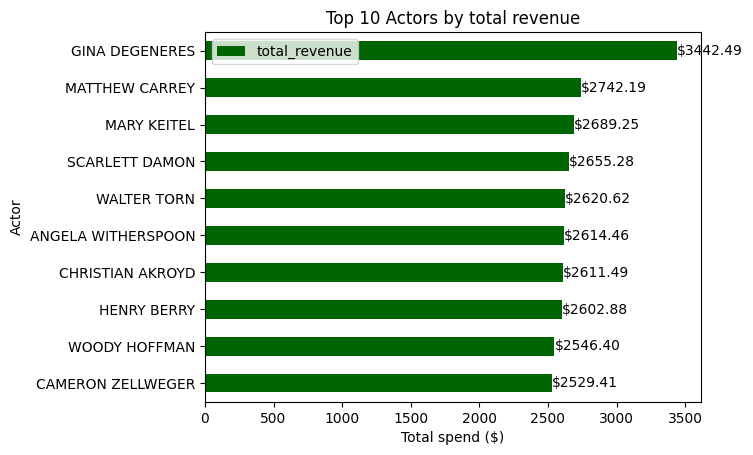

In [13]:
actor_revenue = duckdb.sql("""
SELECT 
    a.first_name || ' ' || a.last_name AS actor_name, 
    SUM(p.amount) AS total_revenue
FROM actor a
JOIN film_actor fa ON a.actor_id = fa.actor_id
JOIN film f ON fa.film_id = f.film_id
JOIN inventory i ON f.film_id = i.film_id
JOIN rental r ON i.inventory_id = r.inventory_id
JOIN payment p ON r.rental_id = p.rental_id
GROUP BY a.actor_id, actor_name
ORDER BY total_revenue DESC
LIMIT 10;
""").df()

ax = actor_revenue.plot(
    kind="barh",
    x="actor_name",
    y="total_revenue",
    title="Top 10 Actors by total revenue",
    xlabel="Total spend ($)",
    ylabel="Actor",
    color="darkgreen"
)

ax.invert_yaxis()

for i, value in enumerate(actor_revenue['total_revenue']):
    ax.text(value + 0.5, i, f"${value:.2f}", va='center')

## Task 2 - graphs

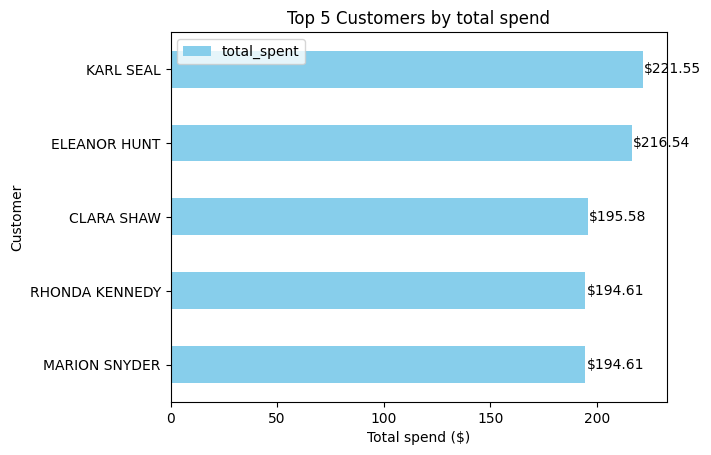

In [14]:
# a) Who are our top 5 customers by total spend? The Manager wants to know so that they can reward them with special offers. Create a bar chart showing the top 5 customers by total spend.

import pandas as pd 

# run query and get DataFrame 
top_customer = duckdb.sql("""
    SELECT 
        c.first_name || ' ' || c.last_name AS customer_name,
        SUM(p.amount) AS total_spent
    FROM customer c
    JOIN payment p ON c.customer_id = p.customer_id
    GROUP BY c.customer_id, customer_name
    ORDER BY total_spent DESC
    LIMIT 5;
""").df()

# plot, top 5 customers by total spend 
ax = top_customer.plot(
    kind="barh",
    x="customer_name",
    y="total_spent",
    title="Top 5 Customers by total spend",
    xlabel="Total spend ($)",
    ylabel="Customer",
    color="skyblue"
)

# from most to least spent 
ax.invert_yaxis()

# shows the exact total_spend for each customer
for i, value in enumerate(top_customer['total_spent']):
    ax.text(value + 0.5, i, f"${value:.2f}", va='center')

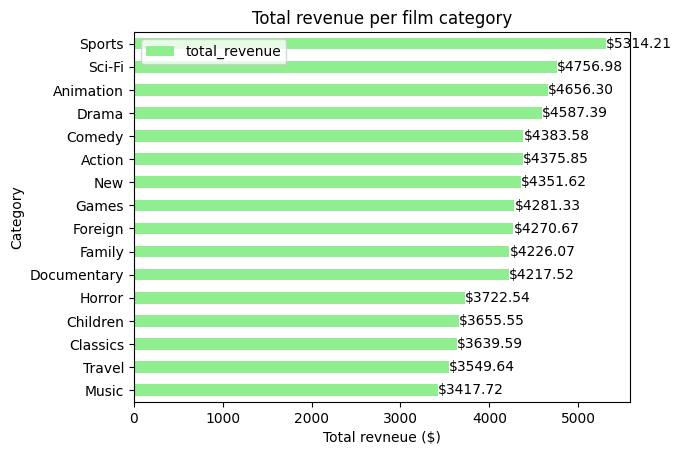

In [15]:
# b) How much money does each category bring in? Make a bar chart showing total revenue per film category

category_revenue = duckdb.sql("""
    SELECT
        c.name AS category_revenue,
        SUM(p.amount) AS total_revenue
    FROM category c
    JOIN film_category fc ON c.category_id = fc.category_id
    JOIN film f ON fc.film_id = f.film_id
    JOIN inventory i ON f.film_id = i.film_id
    JOIN rental r ON i.inventory_id = r.inventory_id
    JOIN payment p ON r.rental_id = p.rental_id
    GROUP BY c.category_id, category_revenue
    ORDER BY total_revenue DESC;
""").df()

category_revenue['total_revenue'] = category_revenue['total_revenue'].astype(float)

# ploting the categories by revenue 
ax = category_revenue.plot(
    kind="barh",
    x="category_revenue",
    y="total_revenue",
    title="Total revenue per film category",
    xlabel="Total revneue ($)",
    ylabel="Category",
    color="lightgreen"
)

# to get descending order from the top 
ax.invert_yaxis()

# add total revenue numbers for each bar
for i, value in enumerate(category_revenue['total_revenue']):
    ax.text(value + 0.5, i, f"${value:.2f}", va='center')